# Proyecto NLP – Análisis de Sentimiento en Tweets  

In [5]:
import os, re, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob

In [6]:
#Instalación Spacy
!pip -q install spacy==3.7.2 wordcloud
!python -m spacy download en_core_web_sm


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


# Carga de datos

In [7]:
path_grande = "training.1600000.processed.noemoticon.csv"
path_small  = "testdata.manual.2009.06.14.csv"
cols = ["polarity","id","date","query","user","text"]

df_grande = pd.read_csv(path_grande, encoding="latin-1", header=None, names=cols)
df_small  = pd.read_csv(path_small,  encoding="latin-1", header=None, names=cols)

print("df_grande shape:", df_grande.shape)
print("df_small  shape:", df_small.shape)
df_grande.head()


df_grande shape: (1600000, 6)
df_small  shape: (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


# EDA en crudo


df_grande (crudo)
            count  prop
polarity              
0         800000   0.5
4         800000   0.5

df_small  (crudo)
           count   prop
polarity              
0           177  0.355
2           139  0.279
4           182  0.365


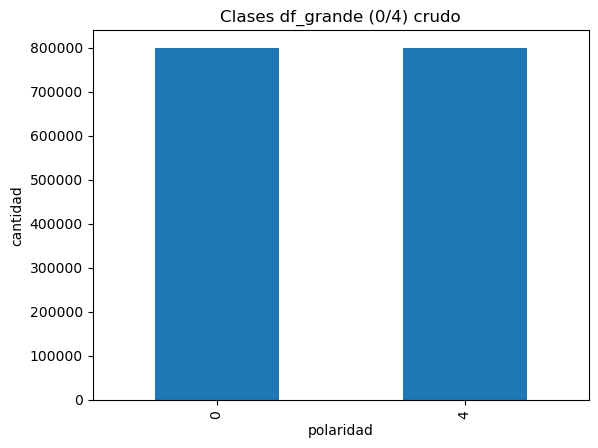

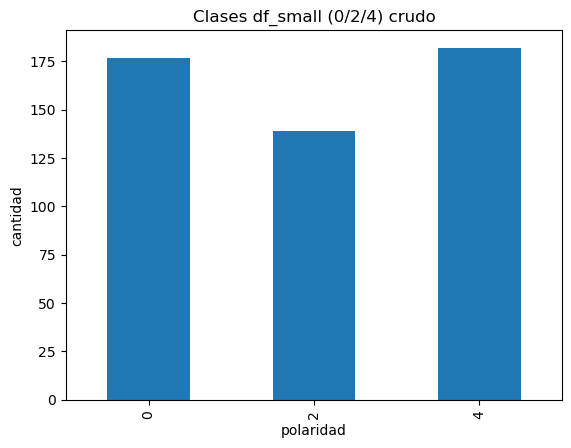

Duplicados eliminados en df_grande: 18534


<Figure size 640x480 with 0 Axes>

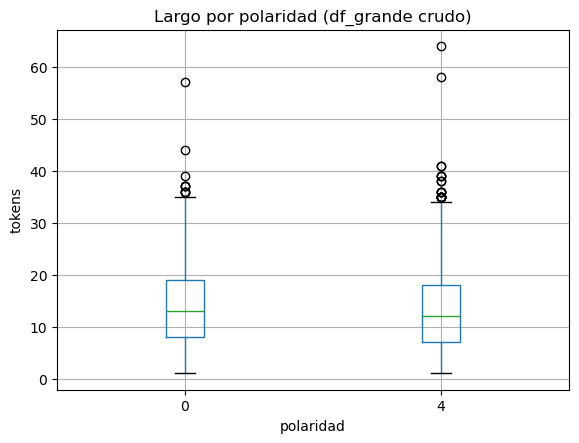

<Figure size 640x480 with 0 Axes>

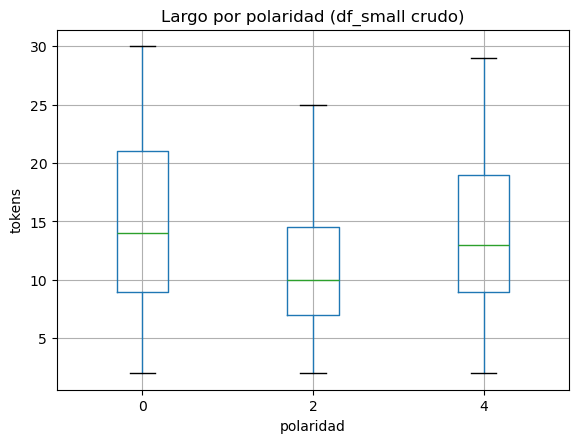

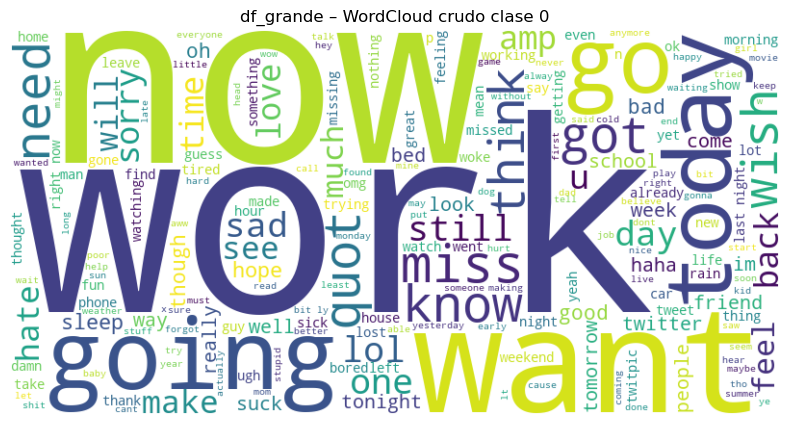

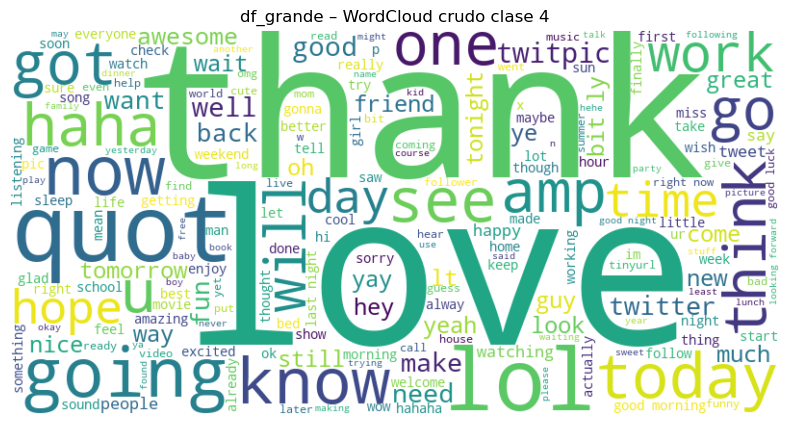

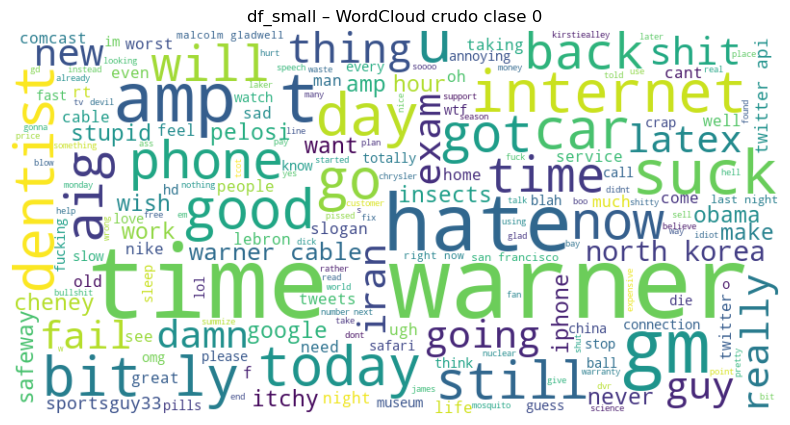

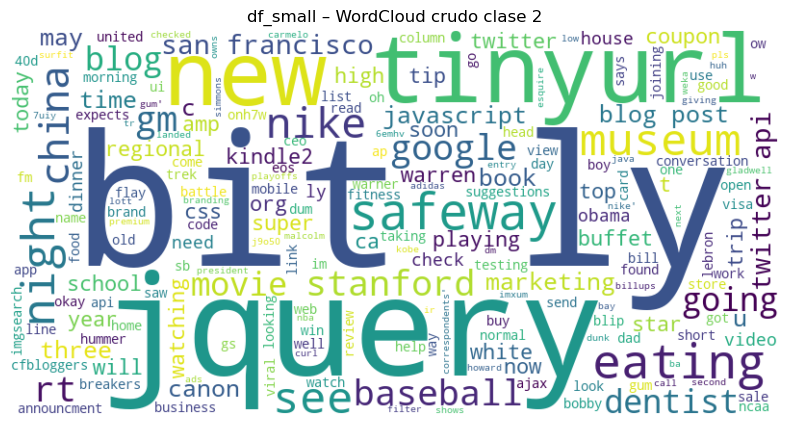

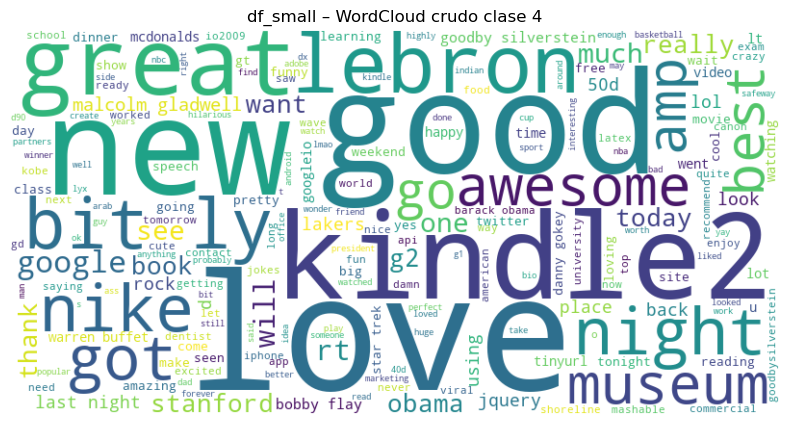

In [8]:
# Elimino columnas no informativas
df_grande = df_grande[["polarity","text"]].copy()
df_small  = df_small[["polarity","text"]].copy()

# 2 Exploración de distribución de las clases
def class_stats(df, name):
    counts = df["polarity"].value_counts().sort_index()
    props  = (counts / counts.sum()).round(3)
    print(f"\n{name}\n", pd.DataFrame({"count": counts, "prop": props}))

class_stats(df_grande, "df_grande (crudo)")
class_stats(df_small,  "df_small  (crudo)")

def plot_class_distribution(df, title):
    counts = df["polarity"].value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("polaridad")
    plt.ylabel("cantidad")
    plt.show()

plot_class_distribution(df_grande, "Clases df_grande (0/4) crudo")
plot_class_distribution(df_small,  "Clases df_small (0/2/4) crudo")

# Eliminación de duplicados en df_grande
before = len(df_grande)
df_grande = df_grande.drop_duplicates(subset=["text"])
print("Duplicados eliminados en df_grande:", before - len(df_grande))

# Analisis de longitud de tweets por clase
df_grande["len_raw"] = df_grande["text"].astype(str).str.split().apply(len)
df_small["len_raw"]  = df_small["text"].astype(str).str.split().apply(len)

plt.figure()
df_grande.boxplot(column="len_raw", by="polarity")
plt.title("Largo por polaridad (df_grande crudo)")
plt.suptitle("")
plt.xlabel("polaridad")
plt.ylabel("tokens")
plt.show()

plt.figure()
df_small.boxplot(column="len_raw", by="polarity")
plt.title("Largo por polaridad (df_small crudo)")
plt.suptitle("")
plt.xlabel("polaridad")
plt.ylabel("tokens")
plt.show()

# 2.5 wordclouds crudos para ver qué palabras se están repitiendo más en cada polaridad de cada dataset
def wc_for_class_raw(df, label, pref=""):
    text = " ".join(df[df.polarity==label]["text"].astype(str)).lower()
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{pref}WordCloud crudo clase {label}")
    plt.show()

wc_for_class_raw(df_grande, 0, "df_grande – ")
wc_for_class_raw(df_grande, 4, "df_grande – ")
wc_for_class_raw(df_small,  0, "df_small – ")
wc_for_class_raw(df_small,  2, "df_small – ")
wc_for_class_raw(df_small,  4, "df_small – ")


# Split de los dataset

In [9]:
X = df_grande["text"]
y = df_grande["polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (1107026,) X_test: (474440,)


# Limpieza con regex (train/test sobre todos los dataset)

In [10]:
url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
hashtag_re = re.compile(r"#(\w+)")

def clean_tweet(text: str) -> str:
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = mention_re.sub(" ", text)
    text = hashtag_re.sub(r"\1", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_train_clean = X_train.apply(clean_tweet)
X_test_clean  = X_test.apply(clean_tweet)

X_ext = df_small["text"]
y_ext = df_small["polarity"]
X_ext_clean = X_ext.apply(clean_tweet)


# Lematización acelerada por partes

In [12]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
nlp.max_length = 2_000_000

def lemmatize_texts(texts, batch_size=5000, n_process=1):
    out=[]
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        toks=[t.lemma_.lower() for t in doc
              if t.is_alpha and t.lemma_!="-PRON-" and t.text.lower() not in STOP_WORDS]
        out.append(" ".join(toks))
    return out

def lemmatize_and_cache_list(texts, out_path, chunk_size=200_000):
    if os.path.exists(out_path):
        return pd.read_parquet(out_path)["text_lemma"].tolist()
    lemmas=[]
    for i in range(0, len(texts), chunk_size):
        chunk = texts[i:i+chunk_size]
        lem_chunk = lemmatize_texts(chunk)
        lemmas.extend(lem_chunk)
        print(f"  - Chunk {i//chunk_size+1} ({len(lemmas)}/{len(texts)})")
    pd.DataFrame({"text_lemma": lemmas}).to_parquet(out_path, index=False)
    return lemmas

X_train_lemma = lemmatize_and_cache_list(X_train_clean.tolist(), "X_train_lemmas.parquet")
X_test_lemma  = lemmatize_and_cache_list(X_test_clean.tolist(),  "X_test_lemmas.parquet", chunk_size=50_000)
X_ext_lemma   = lemmatize_and_cache_list(X_ext_clean.tolist(),   "X_ext_lemmas.parquet",  chunk_size=50_000)

X_train_lemma = pd.Series(X_train_lemma, index=X_train.index)
X_test_lemma  = pd.Series(X_test_lemma,  index=X_test.index)
X_ext_lemma   = pd.Series(X_ext_lemma,   index=X_ext.index)


  - Chunk 1 (200000/1107026)
  - Chunk 2 (400000/1107026)
  - Chunk 3 (600000/1107026)
  - Chunk 4 (800000/1107026)
  - Chunk 5 (1000000/1107026)
  - Chunk 6 (1107026/1107026)
  - Chunk 1 (50000/474440)
  - Chunk 2 (100000/474440)
  - Chunk 3 (150000/474440)
  - Chunk 4 (200000/474440)
  - Chunk 5 (250000/474440)
  - Chunk 6 (300000/474440)
  - Chunk 7 (350000/474440)
  - Chunk 8 (400000/474440)
  - Chunk 9 (450000/474440)
  - Chunk 10 (474440/474440)
  - Chunk 1 (498/498)


# Función para graficar matriz de confusión que la voy a utilizar luego en cada modelo

In [19]:
def plot_confusion(cm, labels, title="Matriz de confusión"):
    plt.figure(figsize=(4.8,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("Real")
    plt.xlabel("Predicho")
    plt.tight_layout()
    plt.show()

# Modelo 1 – Logistic Regression (con dataset grande)

Train
              precision    recall  f1-score   support

           0       0.82      0.78      0.80    553129
           4       0.79      0.83      0.81    553897

    accuracy                           0.80   1107026
   macro avg       0.80      0.80      0.80   1107026
weighted avg       0.80      0.80      0.80   1107026

----------------------------------------------------------
Test interno
              precision    recall  f1-score   support

           0       0.79      0.75      0.77    237056
           4       0.77      0.80      0.78    237384

    accuracy                           0.78    474440
   macro avg       0.78      0.78      0.78    474440
weighted avg       0.78      0.78      0.78    474440



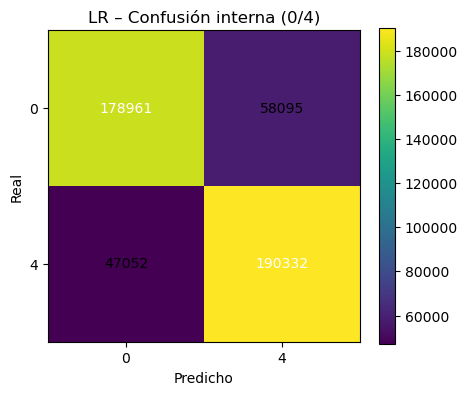

In [14]:
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", LogisticRegression(max_iter=300, n_jobs=-1))
])

lr_pipe.fit(X_train_lemma, y_train)

train_pred_lr = lr_pipe.predict(X_train_lemma)
test_pred_lr  = lr_pipe.predict(X_test_lemma)

print("Train")
print(classification_report(y_train, train_pred_lr))
print("----------------------------------------------------------")
print("Test interno")
print(classification_report(y_test, test_pred_lr))

cm_lr_int = confusion_matrix(y_test, test_pred_lr, labels=[0,4])
plot_confusion(cm_lr_int, labels=[0,4], title="LR – Confusión interna (0/4)")


# Logistic Regression en df_small

Test externo (df_small, 3 clases)
              precision    recall  f1-score   support

           0       0.78      0.65      0.71       177
           2       0.42      0.37      0.39       139
           4       0.59      0.73      0.65       182

    accuracy                           0.60       498
   macro avg       0.60      0.58      0.59       498
weighted avg       0.61      0.60      0.60       498



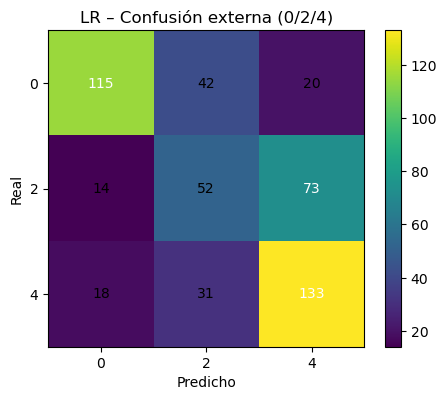

In [15]:
proba_pos_lr = lr_pipe.predict_proba(X_ext_lemma)[:,1]
low_thr, high_thr = 0.4, 0.6

pred_lr_3 = np.where(proba_pos_lr > high_thr, 4,
              np.where(proba_pos_lr < low_thr, 0, 2))

print("Test externo (df_small, 3 clases)")
print(classification_report(y_ext, pred_lr_3))

cm_lr_ext = confusion_matrix(y_ext, pred_lr_3, labels=[0,2,4])
plot_confusion(cm_lr_ext, labels=[0,2,4], title="LR – Confusión externa (0/2/4)")

acc_lr_3 = accuracy_score(y_ext, pred_lr_3)
prec_lr_macro = precision_score(y_ext, pred_lr_3, average="macro", zero_division=0)
prec_lr_weighted = precision_score(y_ext, pred_lr_3, average="weighted", zero_division=0)


# Modelo 2 – Multinomial Naive Bayes con dataset grande

Train
              precision    recall  f1-score   support

           0       0.81      0.79      0.80    553129
           4       0.79      0.81      0.80    553897

    accuracy                           0.80   1107026
   macro avg       0.80      0.80      0.80   1107026
weighted avg       0.80      0.80      0.80   1107026

----------------------------------------------------------
Test interno
              precision    recall  f1-score   support

           0       0.77      0.75      0.76    237056
           4       0.76      0.78      0.77    237384

    accuracy                           0.76    474440
   macro avg       0.76      0.76      0.76    474440
weighted avg       0.76      0.76      0.76    474440



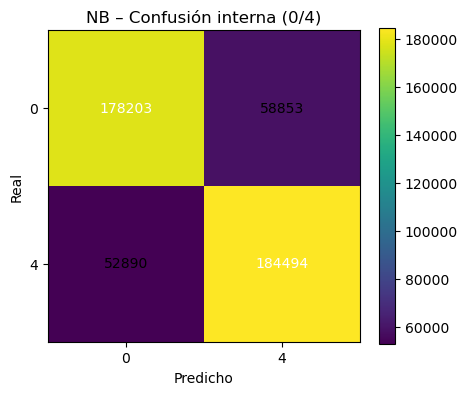

In [16]:
nb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", MultinomialNB())
])

nb_pipe.fit(X_train_lemma, y_train)

train_pred_nb = nb_pipe.predict(X_train_lemma)
test_pred_nb  = nb_pipe.predict(X_test_lemma)

print("Train")
print(classification_report(y_train, train_pred_nb))
print("----------------------------------------------------------")
print("Test interno")
print(classification_report(y_test, test_pred_nb))

cm_nb_int = confusion_matrix(y_test, test_pred_nb, labels=[0,4])
plot_confusion(cm_nb_int, labels=[0,4], title="NB – Confusión interna (0/4)")


# Multinomial Naive Bayes en df_small

Test externo (df_small, 3 clases)
              precision    recall  f1-score   support

           0       0.74      0.64      0.69       177
           2       0.43      0.42      0.42       139
           4       0.59      0.68      0.63       182

    accuracy                           0.59       498
   macro avg       0.59      0.58      0.58       498
weighted avg       0.60      0.59      0.59       498



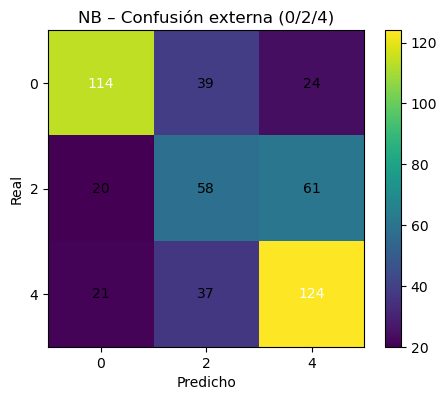

In [20]:
proba_pos_nb = nb_pipe.predict_proba(X_ext_lemma)[:,1]
pred_nb_3 = np.where(proba_pos_nb > high_thr, 4,
              np.where(proba_pos_nb < low_thr, 0, 2))

print("Test externo (df_small, 3 clases)")
print(classification_report(y_ext, pred_nb_3))

cm_nb_ext = confusion_matrix(y_ext, pred_nb_3, labels=[0,2,4])
plot_confusion(cm_nb_ext, labels=[0,2,4], title="NB – Confusión externa (0/2/4)")

acc_nb_3 = accuracy_score(y_ext, pred_nb_3)
prec_nb_macro = precision_score(y_ext, pred_nb_3, average="macro", zero_division=0)
prec_nb_weighted = precision_score(y_ext, pred_nb_3, average="weighted", zero_division=0)


# Modelo 3 – TextBlob baseline en df_small

TextBlob en df_small (3 clases)
              precision    recall  f1-score   support

           0       0.82      0.40      0.53       177
           2       0.50      0.73      0.60       139
           4       0.62      0.72      0.67       182

    accuracy                           0.61       498
   macro avg       0.65      0.62      0.60       498
weighted avg       0.66      0.61      0.60       498



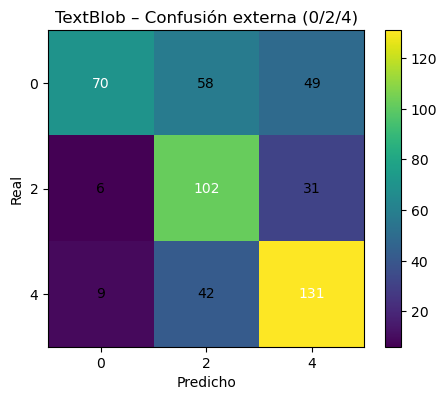

In [21]:
def textblob_predict_3(text):
    pol = TextBlob(text).sentiment.polarity
    if pol > 0.1: return 4
    if pol < -0.1: return 0
    return 2

pred_tb_3 = X_ext_clean.apply(textblob_predict_3).values
print("TextBlob en df_small (3 clases)")
print(classification_report(y_ext, pred_tb_3))

cm_tb_ext = confusion_matrix(y_ext, pred_tb_3, labels=[0,2,4])
plot_confusion(cm_tb_ext, labels=[0,2,4], title="TextBlob – Confusión externa (0/2/4)")

acc_tb_3 = accuracy_score(y_ext, pred_tb_3)
prec_tb_macro = precision_score(y_ext, pred_tb_3, average="macro", zero_division=0)
prec_tb_weighted = precision_score(y_ext, pred_tb_3, average="weighted", zero_division=0)

# Comparativa final

In [30]:
results_3 = pd.DataFrame({
    "modelo": ["Logistic Regression", "Naive Bayes", "TextBlob"],
    "accuracy_df_small": [acc_lr_3, acc_nb_3, acc_tb_3],
}).sort_values("accuracy_df_small", ascending=False)

results_3


,modelo,accuracy_df_small
2,TextBlob,0.608434
0,Logistic Regression,0.602410
1,Naive Bayes,0.594378


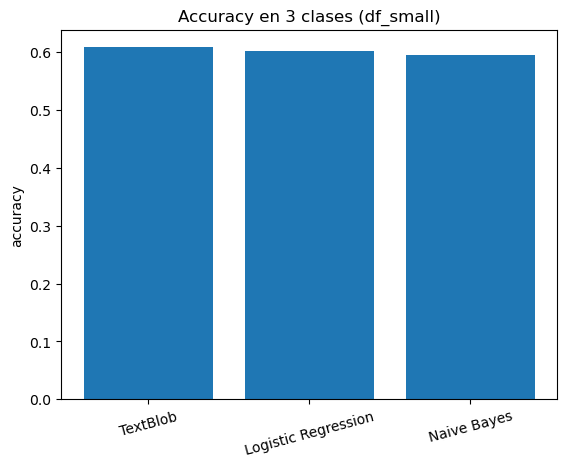

Mejor modelo 3‑clases por accuracy: TextBlob
modelo                TextBlob
accuracy_3clases      0.608434
precision_macro       0.649778
precision_weighted    0.660538
Name: 2, dtype: object


In [24]:
plt.figure()
plt.bar(results_3["modelo"], results_3["accuracy_3clases"])
plt.title("Accuracy en 3 clases (df_small)")
plt.ylabel("accuracy")
plt.xticks(rotation=15)
plt.show()

best_row = results_3.iloc[0]
print("Mejor modelo 3‑clases por accuracy:", best_row["modelo"])
print(best_row)


# Conclusiones 

In [33]:
#Logistic Regression fue el modelo con mejor se desempeñó entre los 2 modelos que entrené ya que tanto la presición con el accuarcy es levemente superior al modelo multinomial naive bayes.

#Si comparo con un modelo preentrenado como textblob, la regresión logistica es levemente interior en accuracy ya que en principio se nota que la precisión en los neutrales es inferior que al textblob, esto se puede entender ya que el modelo fue entrenado nativamente con 2 clases y los neutrales son seleccionados por probabilidad.

#La limitación principal es que la clase neutral (2) no fue aprendida explícitamente durante el entrenamiento (el dataset grande no contiene neutrales). 
#En su lugar, se infiere por descarte usando umbrales de probabilidad. 
#Para este trabajo los modelos entrenados tienen resultados similares al modelo preentrado de textblob siendo levemente inferiores y haciendo que si tuviera que seleccionar un modelo elegiría textblob directo.

In [ ]:

# --- Cosine Similarity Between Class Centroids (TF-IDF) ---

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Assuming your dataframe is named df and has columns: 'polarity' and 'text'
df_eda = df.copy()

# Vectorize
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df_eda['text'])

# Separate by class
X0 = X[df_eda['polarity'] == 0]
X4 = X[df_eda['polarity'] == 4]

# Compute centroids
centroid_0 = X0.mean(axis=0)
centroid_4 = X4.mean(axis=0)

# Cosine similarity
similarity = cosine_similarity(centroid_0, centroid_4)[0][0]

similarity
